# Gamma Correction

Apply gamma correction to the L plane in the L\*a\*b\* color space

The L\*a\*b\* color space separates:
- **L**: Lightness (0 to 100)
- **a**: Green-Red axis
- **b**: Blue-Yellow axis

In [1]:
# Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Set up matplotlib
plt.style.use('default')
%matplotlib inline


## Load Original Image

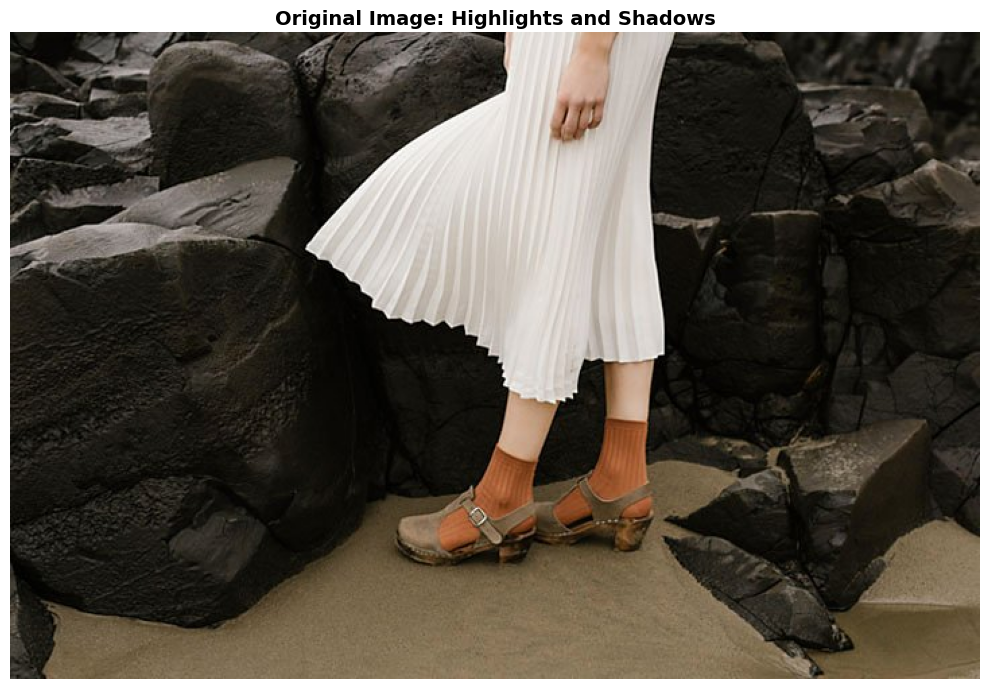

Image shape: (480, 720, 3)


In [3]:
# Load the image
img_bgr = cv2.imread('img/highlights_and_shadows.jpg')
    
if img_bgr is None:
    raise FileNotFoundError("Image file not found. Please check image path.")

# Convert BGR to RGB for display
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Display the original image
plt.figure(figsize=(10, 7))
plt.imshow(img_rgb)
plt.title('Original Image: Highlights and Shadows', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Image shape: {img_rgb.shape}")

## (a) Apply Gamma Correction to L Plane in L\*a\*b\* Color Space

In [4]:
# Define gamma value
gamma = 0.7  # Chosen to brighten shadows while preserving highlights

# Convert RGB to L*a*b* color space
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

# Split into L, a, b channels
L, a, b = cv2.split(img_lab)

print(f"L channel range: [{L.min()}, {L.max()}]")
print(f"a channel range: [{a.min()}, {a.max()}]")
print(f"b channel range: [{b.min()}, {b.max()}]")

# Normalize L channel to [0, 1]
L_normalized = L / 255.0

# Apply gamma correction to L channel
L_corrected = np.power(L_normalized, gamma)

# Convert back to [0, 255]
L_corrected_uint8 = np.uint8(L_corrected * 255)

# Merge the corrected L channel with original a and b channels
img_lab_corrected = cv2.merge([L_corrected_uint8, a, b])

# Convert back to RGB
img_corrected_bgr = cv2.cvtColor(img_lab_corrected, cv2.COLOR_LAB2BGR)
img_corrected_rgb = cv2.cvtColor(img_corrected_bgr, cv2.COLOR_BGR2RGB)

print(f"\nGamma correction applied with Y = {gamma}")


L channel range: [0, 255]
a channel range: [119, 160]
b channel range: [125, 169]

Gamma correction applied with Y = 0.7


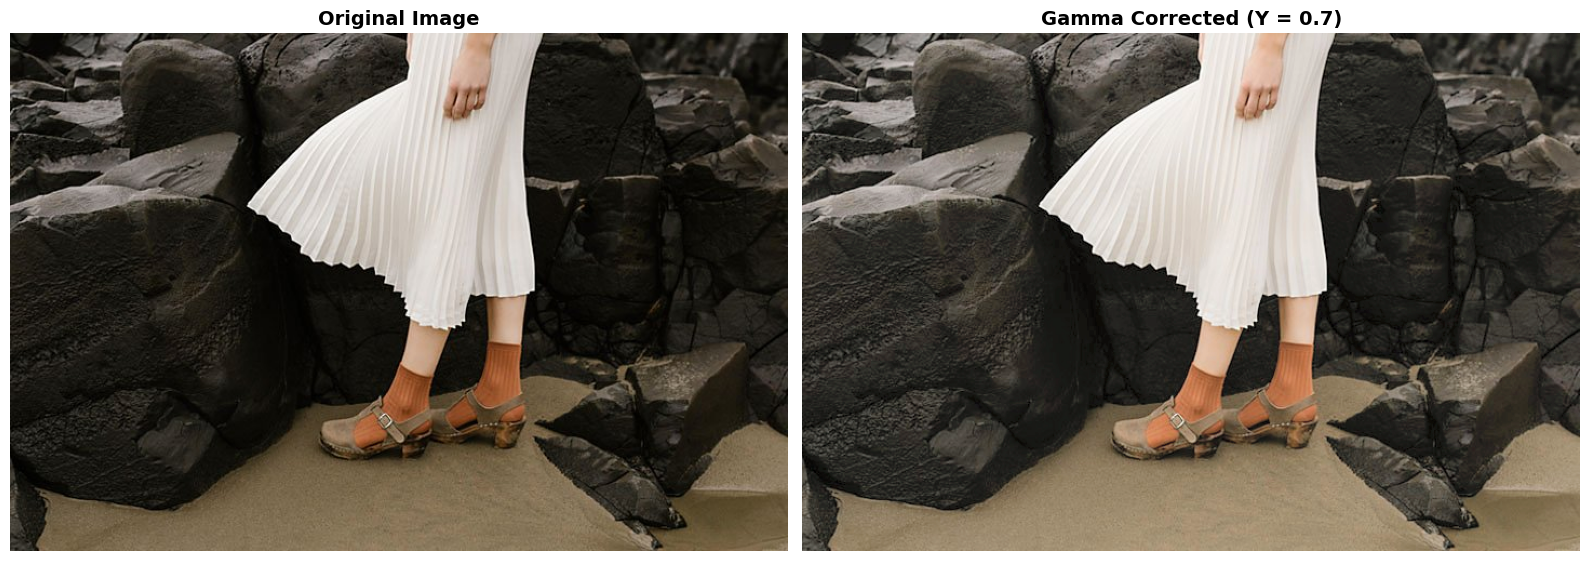

In [5]:
# Display original vs corrected images
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(img_rgb)
axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_corrected_rgb)
axes[1].set_title(f'Gamma Corrected (Y = {gamma})', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()


## (b) Histograms of Original and Corrected Images

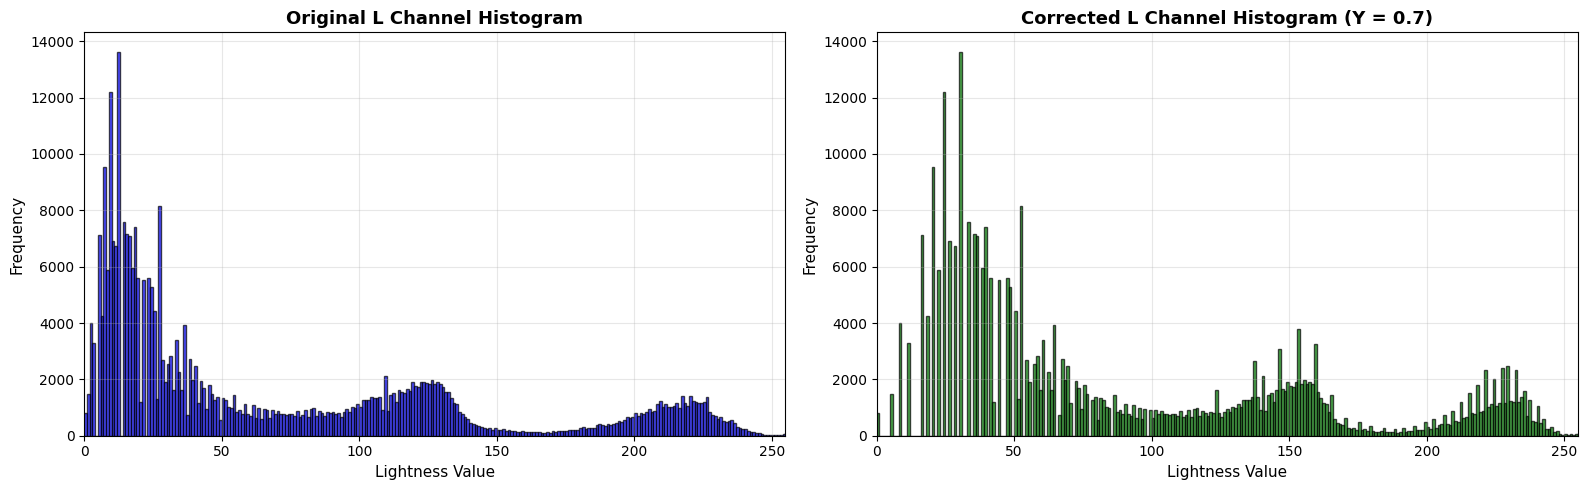

Original L channel - Mean: 71.26, Std: 69.73
Corrected L channel - Mean: 93.51, Std: 69.50


In [7]:
# Compare L channel histograms
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Original L channel histogram
axes[0].hist(L.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7, edgecolor='black')
axes[0].set_title('Original L Channel Histogram', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lightness Value', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 255])

# Corrected L channel histogram
axes[1].hist(L_corrected_uint8.ravel(), bins=256, range=[0, 256], color='green', alpha=0.7, edgecolor='black')
axes[1].set_title(f'Corrected L Channel Histogram (Y = {gamma})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Lightness Value', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 255])

plt.tight_layout()
plt.show()

print(f"Original L channel - Mean: {L.mean():.2f}, Std: {L.std():.2f}")
print(f"Corrected L channel - Mean: {L_corrected_uint8.mean():.2f}, Std: {L_corrected_uint8.std():.2f}")
